,dataset,mean_std_between_temperatures,mean_range_between_temperatures
0,RCWA,0.000700,0.002030
1,Experimental,0.010122,0.027893


Mean standard deviation RCWA:         7.001838e-04
Mean standard deviation experimental: 1.012178e-02
Ratio experimental / RCWA:            14.46


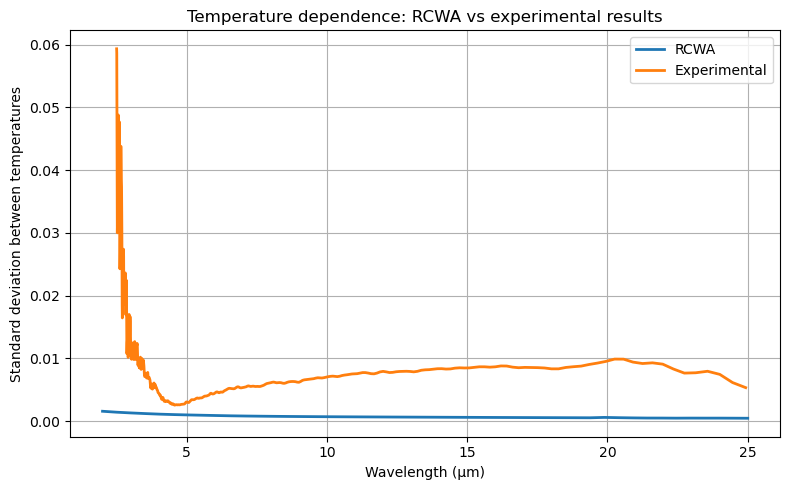

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# ============================================================
# Standard deviation across temperatures
# RCWA results vs experimental results
# ============================================================

# --- Paths ---
rcwa_csv = "RCWA_Inconel_HagenRubens_temperaturesx1.csv"
exp_csv  = "csv/results/1_inconel_temps_corregida_cortada.csv"

# ============================================================
# 1. Load RCWA results
# Expected columns:
# temperature_C, wavelength_um, A_TM
# ============================================================

df_rcwa = pd.read_csv(rcwa_csv)

# Pivot: rows = wavelength, columns = temperature, values = emissivity
rcwa_pivot = df_rcwa.pivot_table(
    index="wavelength_um",
    columns="temperature_C",
    values="A_TM"
).sort_index()

# Standard deviation across temperatures for each wavelength
rcwa_std = rcwa_pivot.std(axis=1)

# Mean standard deviation across all wavelengths
rcwa_mean_std = rcwa_std.mean()

# Range between max and min temperature curves for each wavelength
rcwa_range = rcwa_pivot.max(axis=1) - rcwa_pivot.min(axis=1)
rcwa_mean_range = rcwa_range.mean()


# ============================================================
# 2. Load experimental results
# Expected format:
# first column = wavelength
# remaining columns = emissivity at different temperatures
# ============================================================

df_exp = pd.read_csv(exp_csv)

# Rename first column as Lambda
df_exp.rename(columns={df_exp.columns[0]: "Lambda"}, inplace=True)

# Clean column names
df_exp.columns = df_exp.columns.astype(str).str.strip()

# Convert all columns to numeric when possible
for col in df_exp.columns:
    df_exp[col] = pd.to_numeric(df_exp[col], errors="coerce")

# Detect temperature columns automatically
temp_cols_exp = [c for c in df_exp.columns if c != "Lambda"]

# Standard deviation across temperatures for each wavelength
exp_std = df_exp[temp_cols_exp].std(axis=1)

# Mean standard deviation across all wavelengths
exp_mean_std = exp_std.mean()

# Range between max and min temperature curves for each wavelength
exp_range = df_exp[temp_cols_exp].max(axis=1) - df_exp[temp_cols_exp].min(axis=1)
exp_mean_range = exp_range.mean()


# ============================================================
# 3. Summary table
# ============================================================

summary = pd.DataFrame({
    "dataset": ["RCWA", "Experimental"],
    "mean_std_between_temperatures": [rcwa_mean_std, exp_mean_std],
    "mean_range_between_temperatures": [rcwa_mean_range, exp_mean_range],
})

display(summary)

print(f"Mean standard deviation RCWA:         {rcwa_mean_std:.6e}")
print(f"Mean standard deviation experimental: {exp_mean_std:.6e}")
print(f"Ratio experimental / RCWA:            {exp_mean_std / rcwa_mean_std:.2f}")

# Save summary
summary.to_csv("temperature_std_summary.csv", index=False)


# ============================================================
# 4. Save point-by-point standard deviation
# ============================================================

df_std_rcwa = pd.DataFrame({
    "wavelength_um": rcwa_std.index,
    "std_RCWA": rcwa_std.values,
    "range_RCWA": rcwa_range.values
})

df_std_exp = pd.DataFrame({
    "wavelength_um": df_exp["Lambda"],
    "std_experimental": exp_std.values,
    "range_experimental": exp_range.values
})

df_std_rcwa.to_csv("RCWA_std_between_temperatures.csv", index=False)
df_std_exp.to_csv("experimental_std_between_temperatures.csv", index=False)


# ============================================================
# 5. Plot standard deviation vs wavelength
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    df_std_rcwa["wavelength_um"],
    df_std_rcwa["std_RCWA"],
    label="RCWA",
    linewidth=2
)

plt.plot(
    df_std_exp["wavelength_um"],
    df_std_exp["std_experimental"],
    label="Experimental",
    linewidth=2
)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Standard deviation between temperatures")
plt.title("Temperature dependence: RCWA vs experimental results")
plt.grid(True)
plt.legend()
plt.tight_layout()

# plt.savefig("std_between_temperatures_RCWA_vs_experimental.png", dpi=300, bbox_inches="tight")
plt.show()

In [3]:
import pandas as pd
import numpy as np

# ============================================================
# Mean emissivity at 2.5 µm and 24.5 µm
# RCWA mean of the 4 profiles + experimental mean
# ============================================================

# --- RCWA files ---
profiles = ["x1", "x2", "y1", "y2"]

rcwa_files = {
    profile: f"RCWA_Inconel_HagenRubens_temperatures{profile}.csv"
    for profile in profiles
}

# --- Experimental file ---
exp_csv = "csv/results/1_inconel_temps_corregida_cortada.csv"

# --- Target wavelengths ---
target_wavelengths = [2.5, 24.5]

# --- Temperature to analyse ---
target_temp = 200   # Change this if needed


# ============================================================
# 1. Load RCWA results
# ============================================================

df_list = []

for profile, path in rcwa_files.items():
    df = pd.read_csv(path)
    df["profile"] = profile
    df_list.append(df)

df_rcwa = pd.concat(df_list, ignore_index=True)

# Keep only selected temperature
df_rcwa_temp = df_rcwa[df_rcwa["temperature_C"] == target_temp].copy()


# ============================================================
# 2. RCWA mean at target wavelengths
# ============================================================

rcwa_results = []

for target_lambda in target_wavelengths:
    
    # Find closest available wavelength
    closest_lambda = df_rcwa_temp["wavelength_um"].iloc[
        (df_rcwa_temp["wavelength_um"] - target_lambda).abs().argmin()
    ]
    
    df_lambda = df_rcwa_temp[
        np.isclose(df_rcwa_temp["wavelength_um"], closest_lambda)
    ]
    
    rcwa_results.append({
        "dataset": "RCWA",
        "temperature_C": target_temp,
        "target_wavelength_um": target_lambda,
        "used_wavelength_um": closest_lambda,
        "mean_emissivity": df_lambda["A_TM"].mean(),
        "std_between_profiles": df_lambda["A_TM"].std(),
        "min_emissivity": df_lambda["A_TM"].min(),
        "max_emissivity": df_lambda["A_TM"].max(),
        "n_profiles": df_lambda["profile"].nunique()
    })

df_rcwa_summary = pd.DataFrame(rcwa_results)


# ============================================================
# 3. Load experimental results
# ============================================================

df_exp = pd.read_csv(exp_csv)

# Rename first column as Lambda
df_exp.rename(columns={df_exp.columns[0]: "Lambda"}, inplace=True)

# Clean column names
df_exp.columns = df_exp.columns.astype(str).str.strip()

# Convert to numeric
for col in df_exp.columns:
    df_exp[col] = pd.to_numeric(df_exp[col], errors="coerce")

# Find experimental column corresponding to target_temp
matching_cols = [c for c in df_exp.columns if str(target_temp) in str(c)]

if len(matching_cols) == 0:
    raise ValueError(f"No experimental column found for {target_temp} ºC")

exp_col = matching_cols[0]


# ============================================================
# 4. Experimental emissivity at target wavelengths
# ============================================================

exp_results = []

for target_lambda in target_wavelengths:
    
    idx = (df_exp["Lambda"] - target_lambda).abs().idxmin()
    
    exp_results.append({
        "dataset": "Experimental",
        "temperature_C": target_temp,
        "target_wavelength_um": target_lambda,
        "used_wavelength_um": df_exp.loc[idx, "Lambda"],
        "mean_emissivity": df_exp.loc[idx, exp_col],
        "std_between_profiles": np.nan,
        "min_emissivity": np.nan,
        "max_emissivity": np.nan,
        "n_profiles": np.nan
    })

df_exp_summary = pd.DataFrame(exp_results)


# ============================================================
# 5. Final summary
# ============================================================

df_summary = pd.concat([df_rcwa_summary, df_exp_summary], ignore_index=True)

display(df_summary)

# Save result
df_summary.to_csv(
    f"mean_emissivity_2p5_24p5um_{target_temp}C.csv",
    index=False
)

print(f"Experimental column used: {exp_col}")

,dataset,temperature_C,target_wavelength_um,used_wavelength_um,mean_emissivity,std_between_profiles,min_emissivity,max_emissivity,n_profiles
0,RCWA,200,2.5,2.511111,0.443992,0.023283,0.417191,0.467891,4.0
1,RCWA,200,24.5,24.488889,0.101906,0.005055,0.095498,0.107821,4.0
2,Experimental,200,2.5,2.502400,0.522250,NaN,NaN,NaN,NaN
3,Experimental,200,24.5,24.457000,0.083754,NaN,NaN,NaN,NaN


Experimental column used: 200 ºC


In [7]:
import pandas as pd
import numpy as np
import re

# ============================================================
# Error between RCWA and experimental results by spectral range
# ============================================================

# --- RCWA files ---
profiles = ["x1", "x2", "y1", "y2"]

rcwa_files = {
    profile: f"RCWA_Inconel_HagenRubens_temperatures{profile}.csv"
    for profile in profiles
}

# --- Experimental file ---
exp_csv = "csv/results/1_inconel_temps_corregida_cortada.csv"

# --- Spectral ranges in µm ---
spectral_ranges = {
    "2.5-5 µm":  (2.5, 5.0),
    "5-12 µm":   (5.0, 12.0),
    "12-25 µm":  (12.0, 25.0),
    "2.5-25 µm": (2.5, 25.0),
}

# ============================================================
# 1. Load RCWA results from the 4 profiles
# ============================================================

df_list = []

for profile, path in rcwa_files.items():
    df = pd.read_csv(path)
    df["profile"] = profile
    df_list.append(df)

df_rcwa_all = pd.concat(df_list, ignore_index=True)

# Mean RCWA emissivity of the 4 profiles
df_rcwa_mean = (
    df_rcwa_all
    .groupby(["temperature_C", "wavelength_um"], as_index=False)
    .agg(
        A_RCWA_mean=("A_TM", "mean"),
        A_RCWA_std=("A_TM", "std")
    )
)

# ============================================================
# 2. Load experimental results
# ============================================================

df_exp = pd.read_csv(exp_csv)

# Rename first column as wavelength
df_exp.rename(columns={df_exp.columns[0]: "wavelength_um"}, inplace=True)

# Clean column names
df_exp.columns = df_exp.columns.astype(str).str.strip()

# Convert wavelength to numeric
df_exp["wavelength_um"] = pd.to_numeric(df_exp["wavelength_um"], errors="coerce")

# Convert experimental columns to numeric
for col in df_exp.columns:
    if col != "wavelength_um":
        df_exp[col] = pd.to_numeric(df_exp[col], errors="coerce")

# Convert wide format to long format
df_exp_long = df_exp.melt(
    id_vars="wavelength_um",
    var_name="temperature_label",
    value_name="A_exp"
)

# Extract temperature value from column names
df_exp_long["temperature_C"] = (
    df_exp_long["temperature_label"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df_exp_long = df_exp_long.dropna(subset=["temperature_C"])
df_exp_long["temperature_C"] = df_exp_long["temperature_C"].astype(int)

# ============================================================
# 3. Interpolate experimental results to RCWA wavelength grid
# ============================================================

comparison_list = []

for temp in sorted(df_rcwa_mean["temperature_C"].unique()):

    df_r = df_rcwa_mean[df_rcwa_mean["temperature_C"] == temp].sort_values("wavelength_um")
    df_e = df_exp_long[df_exp_long["temperature_C"] == temp].sort_values("wavelength_um")

    if df_e.empty:
        print(f"No experimental data found for {temp} ºC")
        continue

    # Interpolate experimental curve to the RCWA wavelengths
    A_exp_interp = np.interp(
        df_r["wavelength_um"].values,
        df_e["wavelength_um"].values,
        df_e["A_exp"].values
    )

    df_comp = df_r.copy()
    df_comp["A_exp_interp"] = A_exp_interp
    df_comp["error"] = df_comp["A_RCWA_mean"] - df_comp["A_exp_interp"]
    df_comp["abs_error"] = np.abs(df_comp["error"])
    df_comp["squared_error"] = df_comp["error"] ** 2

    comparison_list.append(df_comp)

df_comparison = pd.concat(comparison_list, ignore_index=True)

# ============================================================
# 4. Calculate errors by spectral range and temperature
# ============================================================

error_results = []

for temp in sorted(df_comparison["temperature_C"].unique()):

    df_temp = df_comparison[df_comparison["temperature_C"] == temp]

    for range_name, (wl_min, wl_max) in spectral_ranges.items():

        df_range = df_temp[
            (df_temp["wavelength_um"] >= wl_min) &
            (df_temp["wavelength_um"] < wl_max)
        ]

        if df_range.empty:
            continue

        mae = df_range["abs_error"].mean()
        rmse = np.sqrt(df_range["squared_error"].mean())
        bias = df_range["error"].mean()
        max_abs_error = df_range["abs_error"].max()
        # Correlation only for the full spectral range 2.5-25 µm
        if range_name == "2.5-25 µm":
            correlation = np.corrcoef(
                df_range["A_RCWA_mean"],
                df_range["A_exp_interp"]
            )[0, 1]
        else:
            correlation = np.nan

        error_results.append({
            "temperature_C": temp,
            "spectral_range": range_name,
            "wavelength_min_um": wl_min,
            "wavelength_max_um": wl_max,
            "MAE": mae,
            "RMSE": rmse,
            "bias_RCWA_minus_exp": bias,
            "max_abs_error": max_abs_error,
            "correlation": correlation,
            "n_points": len(df_range)
        })

df_errors = pd.DataFrame(error_results)

display(df_errors)

# Save results
df_errors.to_csv("RCWA_vs_experimental_error_by_spectral_range.csv", index=False)

# ============================================================
# 5. Optional: average error over all temperatures
# ============================================================

df_errors_mean = (
    df_errors
    .groupby("spectral_range", as_index=False)
    .agg(
        MAE_mean=("MAE", "mean"),
        RMSE_mean=("RMSE", "mean"),
        bias_mean=("bias_RCWA_minus_exp", "mean"),
        max_abs_error_mean=("max_abs_error", "mean")
    )
)

display(df_errors_mean)

df_errors_mean.to_csv("RCWA_vs_experimental_error_by_range_mean_all_temperatures.csv", index=False)

,temperature_C,spectral_range,wavelength_min_um,wavelength_max_um,MAE,RMSE,bias_RCWA_minus_exp,max_abs_error,correlation,n_points
0,200,2.5-5 µm,2.5,5.0,0.044254,0.044746,0.021394,0.057149,NaN,5
1,200,5-12 µm,5.0,12.0,0.032237,0.032325,0.032237,0.038659,NaN,14
2,200,12-25 µm,12.0,25.0,0.029800,0.029925,0.029800,0.032323,NaN,25
3,200,2.5-25 µm,2.5,25.0,0.032218,0.032692,0.029620,0.057149,0.987811,44
4,300,2.5-5 µm,2.5,5.0,0.042200,0.042768,0.042200,0.048278,NaN,5
5,300,5-12 µm,5.0,12.0,0.028003,0.028447,0.028003,0.041047,NaN,14
6,300,12-25 µm,12.0,25.0,0.021051,0.021090,0.021051,0.024141,NaN,25
7,300,2.5-25 µm,2.5,25.0,0.025667,0.026797,0.025667,0.048278,0.998561,44
8,400,2.5-5 µm,2.5,5.0,0.053323,0.053771,0.053323,0.063531,NaN,5
9,400,5-12 µm,5.0,12.0,0.023364,0.024166,0.023364,0.039410,NaN,14


,spectral_range,MAE_mean,RMSE_mean,bias_mean,max_abs_error_mean
0,12-25 µm,0.014930,0.015062,0.014930,0.018617
1,2.5-25 µm,0.022161,0.026690,0.021789,0.072605
2,2.5-5 µm,0.055171,0.056292,0.051905,0.072605
3,5-12 µm,0.023283,0.024150,0.023283,0.038746


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Standard deviation between temperatures for the 4 RCWA profiles
# ============================================================

profiles = ["x1", "x2", "y1", "y2"]

rcwa_files = {
    profile: f"RCWA_Inconel_HagenRubens_temperatures{profile}.csv"
    for profile in profiles
}

all_std_results = []
summary_results = []

for profile, path in rcwa_files.items():

    # Load CSV
    df = pd.read_csv(path)

    # Pivot:
    # rows = wavelength
    # columns = temperature
    # values = emissivity
    df_pivot = df.pivot_table(
        index="wavelength_um",
        columns="temperature_C",
        values="A_TM"
    ).sort_index()

    # Standard deviation between temperatures at each wavelength
    std_temp = df_pivot.std(axis=1)

    # Range between maximum and minimum temperature at each wavelength
    range_temp = df_pivot.max(axis=1) - df_pivot.min(axis=1)

    # Save point-by-point results
    df_std_profile = pd.DataFrame({
        "profile": profile,
        "wavelength_um": std_temp.index,
        "std_between_temperatures": std_temp.values,
        "range_between_temperatures": range_temp.values
    })

    all_std_results.append(df_std_profile)

    # Summary values for this profile
    summary_results.append({
        "profile": profile,
        "mean_std_between_temperatures": std_temp.mean(),
        "max_std_between_temperatures": std_temp.max(),
        "mean_range_between_temperatures": range_temp.mean(),
        "max_range_between_temperatures": range_temp.max()
    })

# ============================================================
# Combine results
# ============================================================

df_std_all = pd.concat(all_std_results, ignore_index=True)
df_summary = pd.DataFrame(summary_results)

display(df_summary)

# Save CSVs
# df_std_all.to_csv("std_between_temperatures_4_profiles_by_wavelength.csv", index=False)
# df_summary.to_csv("std_between_temperatures_4_profiles_summary.csv", index=False

,profile,mean_std_between_temperatures,max_std_between_temperatures,mean_range_between_temperatures,max_range_between_temperatures
0,x1,0.000700,0.001558,0.002030,0.004516
1,x2,0.000712,0.001576,0.002065,0.004568
2,y1,0.000664,0.001428,0.001925,0.004139
3,y2,0.000659,0.001450,0.001910,0.004203


In [11]:
import pandas as pd

# ============================================================
# Mean total emissivity at 200 ºC for each RCWA profile
# ============================================================

profiles = ["x1", "x2", "y1", "y2"]

rcwa_files = {
    profile: f"RCWA_Inconel_HagenRubens_temperatures{profile}.csv"
    for profile in profiles
}

target_temp = 200

results = []

for profile, path in rcwa_files.items():
    
    df = pd.read_csv(path)
    
    # Filter temperature
    df_temp = df[df["temperature_C"] == target_temp].copy()
    
    # Mean emissivity over the whole wavelength range
    mean_emissivity = df_temp["A_TM"].mean()
    
    results.append({
        "profile": profile,
        "temperature_C": target_temp,
        "mean_emissivity": mean_emissivity,
        "min_emissivity": df_temp["A_TM"].min(),
        "max_emissivity": df_temp["A_TM"].max(),
        "std_emissivity": df_temp["A_TM"].std(),
        "wavelength_min_um": df_temp["wavelength_um"].min(),
        "wavelength_max_um": df_temp["wavelength_um"].max(),
        "n_points": len(df_temp)
    })

df_mean_profiles = pd.DataFrame(results)

display(df_mean_profiles)

# Save results
# df_mean_profiles.to_csv("mean_emissivity_200C_each_profile.csv", index=False)

,profile,temperature_C,mean_emissivity,min_emissivity,max_emissivity,std_emissivity,wavelength_min_um,wavelength_max_um,n_points
0,x1,200,0.187155,0.102645,0.540767,0.102144,2.0,25.0,46
1,x2,200,0.171370,0.094124,0.515943,0.094236,2.0,25.0,46
2,y1,200,0.175673,0.100762,0.485877,0.087447,2.0,25.0,46
3,y2,200,0.189665,0.106729,0.539852,0.096064,2.0,25.0,46


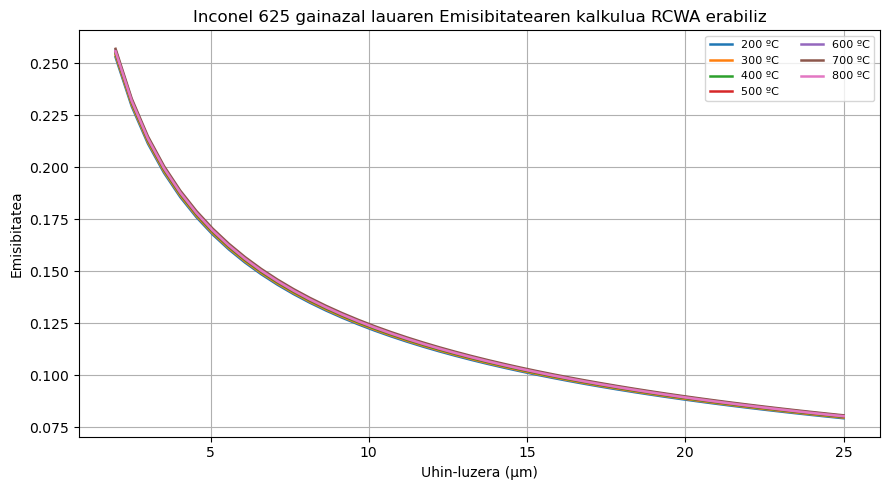

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Plot flat Inconel surface RCWA results for all temperatures
# and save as PNG
# ============================================================

# --- Load CSV ---
df = pd.read_csv("RCWA_Inconel_HagenRubens_flat.csv")

# --- Sort ---
df = df.sort_values(["temperature_C", "wavelength_um"])

# --- Temperatures available in the CSV ---
temperatures = sorted(df["temperature_C"].unique())

# --- Plot ---
plt.figure(figsize=(9, 5))

for temp in temperatures:
    df_temp = df[df["temperature_C"] == temp].sort_values("wavelength_um")

    plt.plot(
        df_temp["wavelength_um"],
        df_temp["A_TM"],
        linewidth=1.8,
        label=f"{temp} ºC"
    )

plt.xlabel("Uhin-luzera (µm)")
plt.ylabel("Emisibitatea")
plt.title("Inconel 625 gainazal lauaren Emisibitatearen kalkulua RCWA erabiliz")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()

# --- Save before show ---
plt.savefig("inconel_flat_surface_results.png", dpi=300, bbox_inches="tight")

plt.show()